# Project FORESIGHT — Final Dashboard

## AI-Powered Demand & Inventory Intelligence Platform

This notebook creates the final analytical dashboard for Project FORESIGHT.

### Dashboard Objectives

The dashboard combines:

- Sales performance
- Demand trends
- Inventory position
- Inventory risk
- Stockout risk
- Overstock risk
- Replenishment recommendations
- Forecast model performance
- SKU-level inventory intelligence

### Main Decision Questions

1. How much demand is being generated?
2. What is the current inventory position?
3. Which SKUs are at stockout risk?
4. Which SKUs are overstocked?
5. How much inventory should be replenished?
6. How accurate is the forecasting model?

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# Define processed-data directory

processed_path = "../data/processed"

print("Processed data path:")
print(processed_path)

print("\nFolder exists:", os.path.exists(processed_path))

Processed data path:
../data/processed

Folder exists: True


In [3]:
# Load analysis-ready dataset

analysis_df = pd.read_csv(
    os.path.join(
        processed_path,
        "analysis_ready.csv"
    )
)

print("Analysis dataset loaded.")
print("Shape:", analysis_df.shape)

Analysis dataset loaded.
Shape: (20906, 26)


In [4]:
# Load detailed inventory risk analysis

risk_df = pd.read_csv(
    os.path.join(
        processed_path,
        "inventory_risk_analysis.csv"
    )
)

print("Inventory risk analysis loaded.")
print("Shape:", risk_df.shape)

Inventory risk analysis loaded.
Shape: (21840, 14)


In [5]:
# Load inventory risk summary

risk_summary_df = pd.read_csv(
    os.path.join(
        processed_path,
        "inventory_risk_summary.csv"
    )
)

print("Inventory risk summary loaded.")
print("Shape:", risk_summary_df.shape)

Inventory risk summary loaded.
Shape: (3, 3)


In [6]:
# Load inventory recommendations

recommendation_df = pd.read_csv(
    os.path.join(
        processed_path,
        "inventory_recommendations.csv"
    )
)

print("Inventory recommendations loaded.")
print("Shape:", recommendation_df.shape)

Inventory recommendations loaded.
Shape: (20906, 15)


In [7]:
# Load SKU-level inventory summary

sku_inventory_df = pd.read_csv(
    os.path.join(
        processed_path,
        "sku_inventory_summary.csv"
    )
)

print("SKU inventory summary loaded.")
print("Shape:", sku_inventory_df.shape)

SKU inventory summary loaded.
Shape: (40, 5)


In [8]:
# Load model evaluation results

evaluation_path = os.path.join(
    processed_path,
    "model_evaluation_summary.csv"
)

if os.path.exists(evaluation_path):

    model_evaluation_df = pd.read_csv(
        evaluation_path
    )

    print("Model evaluation loaded.")
    print("Shape:", model_evaluation_df.shape)

else:

    model_evaluation_df = pd.DataFrame()

    print(
        "model_evaluation_summary.csv not found."
    )

Model evaluation loaded.
Shape: (1, 8)


In [9]:
# Load baseline model performance

baseline_path = os.path.join(
    processed_path,
    "baseline_model_performance.csv"
)

if os.path.exists(baseline_path):

    baseline_df = pd.read_csv(
        baseline_path
    )

    print("Baseline model performance loaded.")
    print("Shape:", baseline_df.shape)

else:

    baseline_df = pd.DataFrame()

    print(
        "baseline_model_performance.csv not found."
    )

baseline_model_performance.csv not found.


In [10]:
# Load daily inventory risk trend

trend_path = os.path.join(
    processed_path,
    "daily_inventory_risk_trend.csv"
)

if os.path.exists(trend_path):

    risk_trend_df = pd.read_csv(
        trend_path
    )

    print("Daily inventory risk trend loaded.")
    print("Shape:", risk_trend_df.shape)

else:

    risk_trend_df = pd.DataFrame()

    print(
        "daily_inventory_risk_trend.csv not found."
    )

Daily inventory risk trend loaded.
Shape: (546, 4)


In [11]:
# Display available columns for dashboard datasets

print("ANALYSIS DATASET")
print(analysis_df.columns.tolist())

print("\nRISK DATASET")
print(risk_df.columns.tolist())

print("\nRECOMMENDATION DATASET")
print(recommendation_df.columns.tolist())

print("\nSKU INVENTORY DATASET")
print(sku_inventory_df.columns.tolist())

ANALYSIS DATASET
['date', 'sku_id', 'units_sold', 'revenue', 'price', 'promo_flag', 'calculated_revenue', 'revenue_difference', 'revenue_consistency_flag', 'category', 'subcategory', 'launch_date', 'unit_cost', 'list_price', 'sku_quality_flag', 'week', 'month', 'season', 'is_holiday', 'promo_event', 'promo_flag_calendar', 'on_hand_units', 'on_order_units', 'lead_time_days', 'reorder_point', 'inventory_quality_flag']

RISK DATASET
['date', 'sku_id', 'on_hand_units', 'on_order_units', 'lead_time_days', 'reorder_point', 'daily_demand', 'average_daily_demand', 'inventory_coverage_days', 'lead_time_demand', 'below_reorder_point', 'stockout_flag', 'lead_time_risk', 'risk_category']

RECOMMENDATION DATASET
['date', 'sku_id', 'category', 'subcategory', 'units_sold', 'on_hand_units', 'on_order_units', 'lead_time_days', 'reorder_point', 'inventory_position', 'target_inventory', 'recommended_order_qty', 'inventory_risk', 'recommendation_priority', 'recommendation']

SKU INVENTORY DATASET
['sku_id

In [12]:
# Convert date fields where available

if "date" in analysis_df.columns:
    analysis_df["date"] = pd.to_datetime(
        analysis_df["date"],
        errors="coerce"
    )

if "date" in risk_df.columns:
    risk_df["date"] = pd.to_datetime(
        risk_df["date"],
        errors="coerce"
    )

if "date" in recommendation_df.columns:
    recommendation_df["date"] = pd.to_datetime(
        recommendation_df["date"],
        errors="coerce"
    )

if "date" in risk_trend_df.columns:
    risk_trend_df["date"] = pd.to_datetime(
        risk_trend_df["date"],
        errors="coerce"
    )

print("Date conversion completed.")

Date conversion completed.


## 1. Executive KPI Dashboard

The first dashboard section provides high-level business KPIs.

Key indicators include:

- Total units sold
- Total revenue
- Average selling price
- Number of SKUs
- Inventory position
- Stockout-risk records
- Overstock-risk records
- Recommended replenishment quantity

In [13]:
# Calculate executive KPIs

total_units_sold = analysis_df["units_sold"].sum()

total_revenue = analysis_df["revenue"].sum()

average_price = analysis_df["price"].mean()

unique_skus = analysis_df["sku_id"].nunique()

total_on_hand = analysis_df["on_hand_units"].sum()

total_on_order = analysis_df["on_order_units"].sum()

total_inventory_position = (
    total_on_hand + total_on_order
)

print("Total Units Sold:", total_units_sold)
print("Total Revenue:", total_revenue)
print("Average Selling Price:", average_price)
print("Unique SKUs:", unique_skus)
print("On-Hand Units:", total_on_hand)
print("On-Order Units:", total_on_order)
print(
    "Inventory Position:",
    total_inventory_position
)

Total Units Sold: 1270795.0
Total Revenue: 4922297084.34
Average Selling Price: 4070.395134954058
Unique SKUs: 40
On-Hand Units: 435422.0
On-Order Units: 1908826
Inventory Position: 2344248.0


In [14]:
# Calculate inventory risk KPIs

if "inventory_risk" in recommendation_df.columns:

    stockout_records = (
        recommendation_df["inventory_risk"]
        == "STOCKOUT_RISK"
    ).sum()

    overstock_records = (
        recommendation_df["inventory_risk"]
        == "OVERSTOCK_RISK"
    ).sum()

    healthy_records = (
        recommendation_df["inventory_risk"]
        == "HEALTHY"
    ).sum()

else:

    stockout_records = 0
    overstock_records = 0
    healthy_records = 0

if "recommended_order_qty" in recommendation_df.columns:

    total_recommended_order = (
        recommendation_df["recommended_order_qty"]
        .sum()
    )

else:

    total_recommended_order = 0

print("Stockout Risk Records:", stockout_records)
print("Overstock Risk Records:", overstock_records)
print("Healthy Records:", healthy_records)
print(
    "Recommended Order Units:",
    total_recommended_order
)

Stockout Risk Records: 19208
Overstock Risk Records: 665
Healthy Records: 1033
Recommended Order Units: 4944578


In [15]:
# Create executive KPI table

kpi_table = pd.DataFrame({
    "KPI": [
        "Total Units Sold",
        "Total Revenue",
        "Average Selling Price",
        "Unique SKUs",
        "On-Hand Units",
        "On-Order Units",
        "Inventory Position",
        "Stockout Risk Records",
        "Overstock Risk Records",
        "Recommended Order Units"
    ],
    "Value": [
        total_units_sold,
        total_revenue,
        average_price,
        unique_skus,
        total_on_hand,
        total_on_order,
        total_inventory_position,
        stockout_records,
        overstock_records,
        total_recommended_order
    ]
})

kpi_table

,KPI,Value
0,Total Units Sold,1.270795e+06
1,Total Revenue,4.922297e+09
2,Average Selling Price,4.070395e+03
3,Unique SKUs,4.000000e+01
4,On-Hand Units,4.354220e+05
5,On-Order Units,1.908826e+06
6,Inventory Position,2.344248e+06
7,Stockout Risk Records,1.920800e+04
8,Overstock Risk Records,6.650000e+02
9,Recommended Order Units,4.944578e+06


## 2. Sales & Demand Trend

The sales trend shows how demand changes over time.

This helps identify:

- Increasing demand
- Decreasing demand
- Seasonal patterns
- Unusual demand periods

In [16]:
# Aggregate sales by date

daily_sales = (
    analysis_df
    .groupby("date")
    .agg(
        units_sold=("units_sold", "sum"),
        revenue=("revenue", "sum")
    )
    .reset_index()
)

daily_sales.head()

,date,units_sold,revenue
0,2025-01-01,1358.0,5547857.60
1,2025-01-02,1394.0,5498482.84
2,2025-01-03,1616.0,6393650.07
3,2025-01-04,1636.0,6665035.04
4,2025-01-05,1458.0,6232519.54


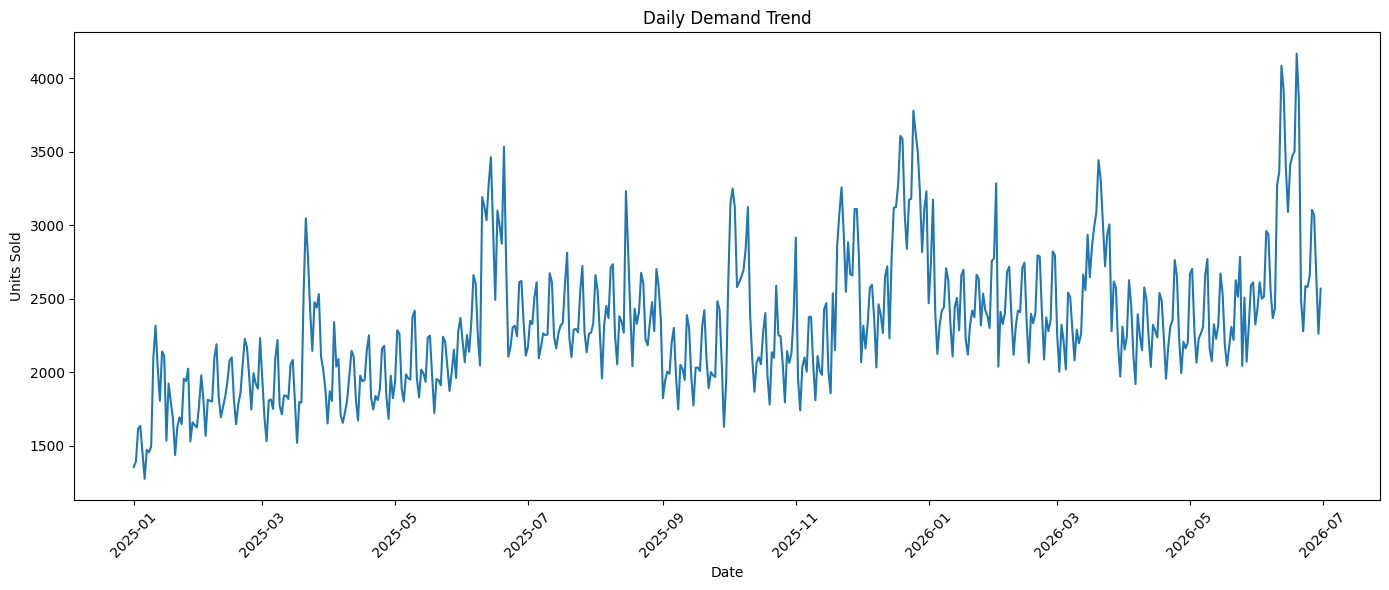

In [17]:
# Plot daily units sold

plt.figure(figsize=(14, 6))

plt.plot(
    daily_sales["date"],
    daily_sales["units_sold"]
)

plt.title("Daily Demand Trend")
plt.xlabel("Date")
plt.ylabel("Units Sold")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

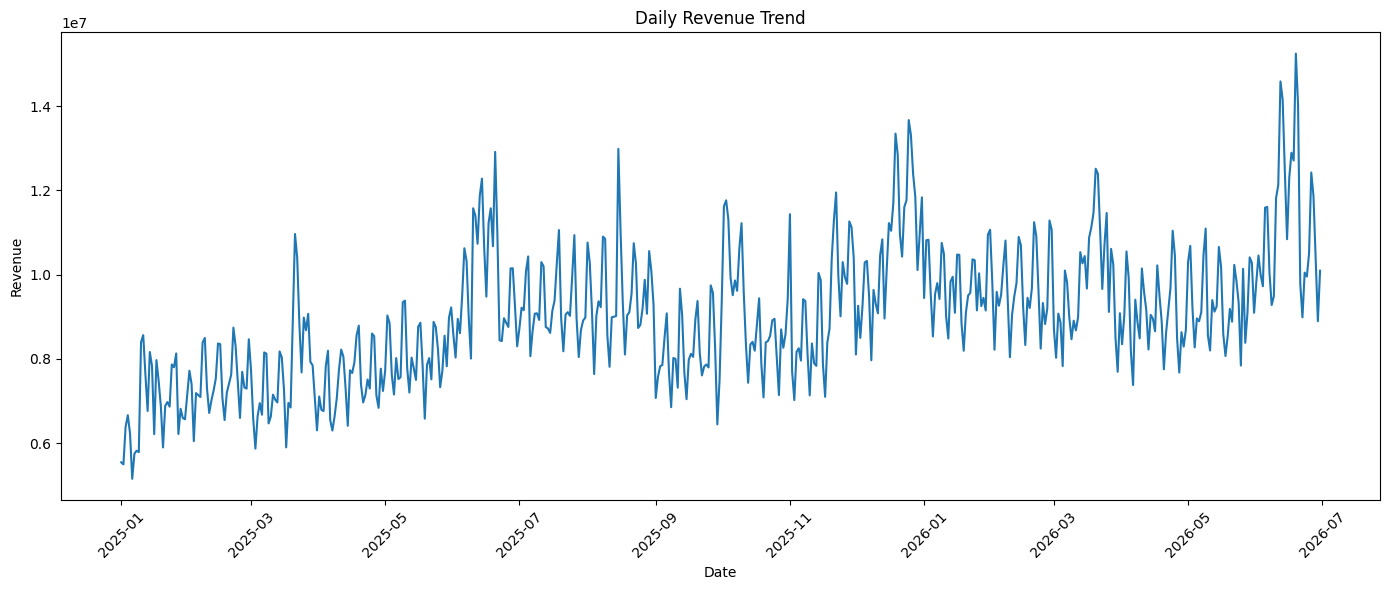

In [18]:
# Plot daily revenue

plt.figure(figsize=(14, 6))

plt.plot(
    daily_sales["date"],
    daily_sales["revenue"]
)

plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 3. Inventory Risk Dashboard

This section identifies the overall inventory risk profile.

Risk categories:

- STOCKOUT_RISK
- OVERSTOCK_RISK
- HEALTHY

In [19]:
# Calculate inventory risk distribution

if "inventory_risk" in recommendation_df.columns:

    risk_distribution = (
        recommendation_df["inventory_risk"]
        .value_counts()
        .reset_index()
    )

    risk_distribution.columns = [
        "Risk_Category",
        "Record_Count"
    ]

    risk_distribution

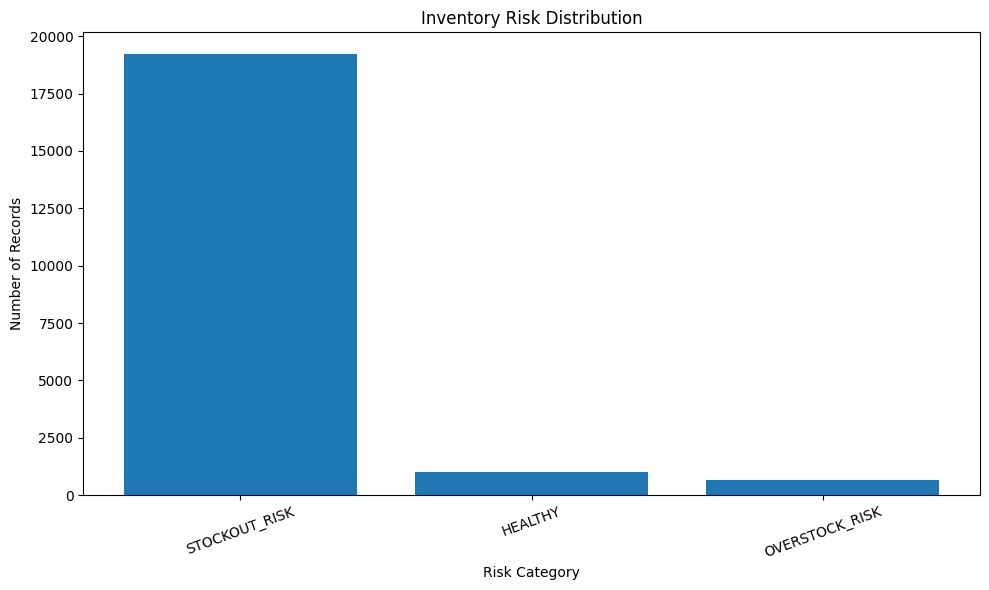

In [20]:
# Plot inventory risk distribution

if "risk_distribution" in globals():

    plt.figure(figsize=(10, 6))

    plt.bar(
        risk_distribution["Risk_Category"],
        risk_distribution["Record_Count"]
    )

    plt.title("Inventory Risk Distribution")
    plt.xlabel("Risk Category")
    plt.ylabel("Number of Records")

    plt.xticks(rotation=20)

    plt.tight_layout()
    plt.show()

## 4. Stockout Risk Analysis

Stockout risk represents SKUs where available and incoming inventory may not be sufficient to satisfy expected demand.

These SKUs should receive the highest operational priority.

In [21]:
# Identify stockout-risk records

if "inventory_risk" in recommendation_df.columns:

    stockout_df = (
        recommendation_df[
            recommendation_df["inventory_risk"]
            == "STOCKOUT_RISK"
        ]
        .copy()
    )

    print(
        "Stockout-risk records:",
        len(stockout_df)
    )

    stockout_df.head(20)

Stockout-risk records: 19208


In [22]:
# Identify SKUs requiring the highest replenishment

if "recommended_order_qty" in recommendation_df.columns:

    top_replenishment = (
        recommendation_df
        .sort_values(
            "recommended_order_qty",
            ascending=False
        )
        .head(20)
    )

    top_replenishment

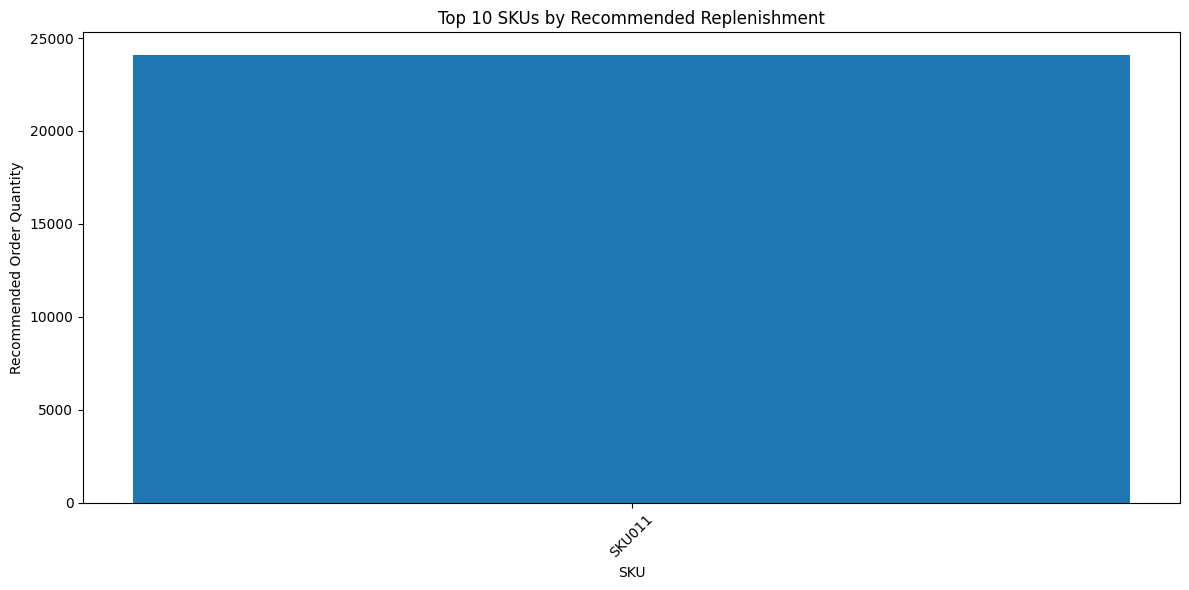

In [23]:
# Plot top replenishment requirements

if "top_replenishment" in globals():

    plot_data = (
        top_replenishment
        .groupby("sku_id")["recommended_order_qty"]
        .sum()
        .sort_values(ascending=False)
        .head(10)
    )

    plt.figure(figsize=(12, 6))

    plt.bar(
        plot_data.index.astype(str),
        plot_data.values
    )

    plt.title(
        "Top 10 SKUs by Recommended Replenishment"
    )

    plt.xlabel("SKU")
    plt.ylabel("Recommended Order Quantity")

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

## 5. Overstock Analysis

Overstock risk highlights SKUs where inventory is significantly above the target inventory level.

These products may require:

- Reduced purchasing
- Inventory holding
- Promotion
- Demand stimulation
- Inventory redistribution

In [24]:
# Identify overstock-risk records

if "inventory_risk" in recommendation_df.columns:

    overstock_df = (
        recommendation_df[
            recommendation_df["inventory_risk"]
            == "OVERSTOCK_RISK"
        ]
        .copy()
    )

    print(
        "Overstock-risk records:",
        len(overstock_df)
    )

    overstock_df.head(20)

Overstock-risk records: 665


## 6. Inventory Risk Trend

The daily inventory risk trend provides a time-based view of inventory risk.

This helps identify whether risk is:

- Increasing
- Decreasing
- Stable

In [27]:
# Inspect daily risk trend data

if not risk_trend_df.empty:

    display(
        risk_trend_df.head()
    )

    print(
        "\nColumns:",
        risk_trend_df.columns.tolist()
    )
else:
    print(
        "Daily inventory risk trend is not available."
    )

,date,stockout_records,reorder_point_breaches,lead_time_risk_records
0,2025-01-01,1,27,35
1,2025-01-02,1,32,37
2,2025-01-03,4,29,33
3,2025-01-04,5,32,39
4,2025-01-05,11,35,39



Columns: ['date', 'stockout_records', 'reorder_point_breaches', 'lead_time_risk_records']


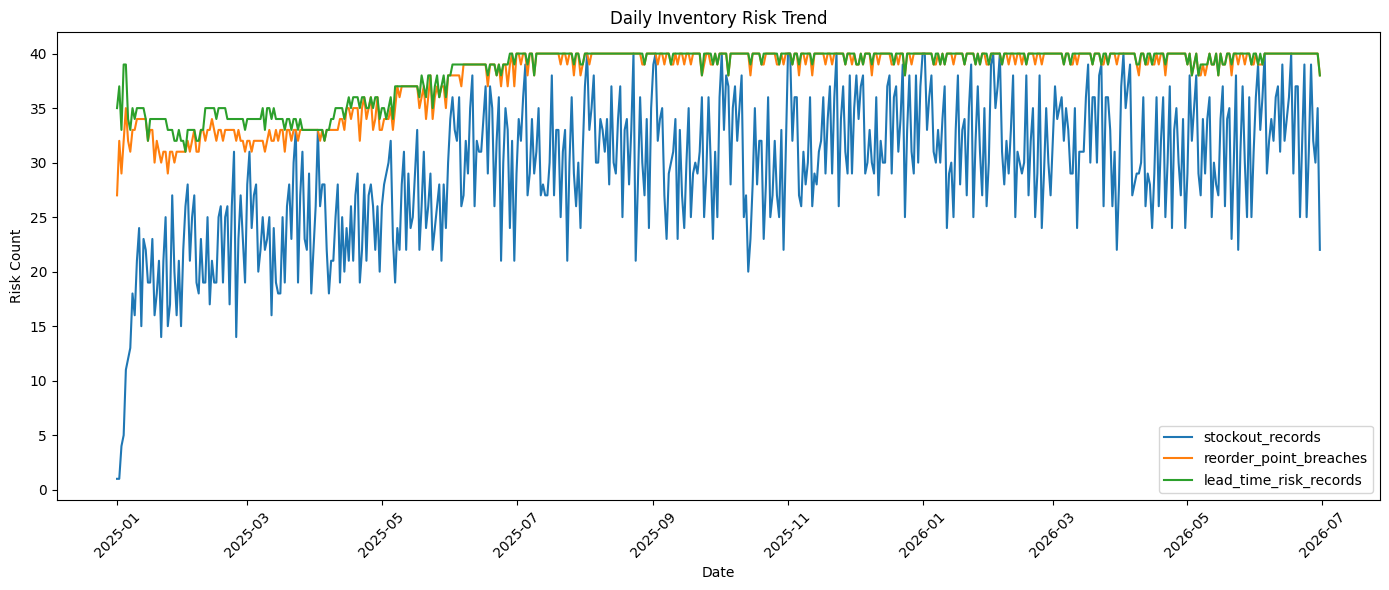

In [28]:
# Plot available daily inventory risk trends

if not risk_trend_df.empty:

    numeric_columns = (
        risk_trend_df
        .select_dtypes(include=np.number)
        .columns
        .tolist()
    )

    if numeric_columns:

        plt.figure(figsize=(14, 6))

        for column in numeric_columns:

            plt.plot(
                risk_trend_df["date"],
                risk_trend_df[column],
                label=column
            )

        plt.title(
            "Daily Inventory Risk Trend"
        )

        plt.xlabel("Date")
        plt.ylabel("Risk Count")

        plt.legend()

        plt.xticks(rotation=45)

        plt.tight_layout()
        plt.show()

## 7. Forecast Model Performance

The forecasting model is evaluated using:

- MAE
- RMSE
- MAPE
- WAPE
- R²

These metrics indicate how accurately demand was forecast.

In [29]:
# Display model evaluation metrics

if not model_evaluation_df.empty:

    model_evaluation_df
else:

    print(
        "Model evaluation results are not available."
    )

In [30]:
# Plot model evaluation metrics

if not model_evaluation_df.empty:

    numeric_metrics = (
        model_evaluation_df
        .select_dtypes(include=np.number)
        .columns
        .tolist()
    )

    if numeric_metrics:

        plt.figure(figsize=(10, 6))

        plt.bar(
            model_evaluation_df["Metric"],
            model_evaluation_df["Value"]
        )

        plt.title(
            "Demand Forecast Model Evaluation"
        )

        plt.xlabel("Metric")
        plt.ylabel("Value")

        plt.xticks(rotation=30)

        plt.tight_layout()
        plt.show()

KeyError: 'Metric'

<Figure size 1000x600 with 0 Axes>

## 8. SKU-Level Inventory Intelligence

This section provides a SKU-level view of:

- Average inventory position
- Average demand
- Target inventory
- Recommended order quantity
- Stockout-risk days
- Overstock-risk days

In [31]:
# Display SKU-level inventory summary

sku_inventory_df.head(20)

,sku_id,average_inventory_position,average_target_inventory,total_recommended_order_qty,risk_records
0,SKU001,104.730769,255.0,82386,544
1,SKU002,51.615970,107.0,31006,524
2,SKU003,21.276557,48.0,14626,541
3,SKU004,113.044706,360.0,112977,420
4,SKU005,160.302198,460.0,163666,545
5,SKU006,24.783883,129.0,56902,546
6,SKU007,158.875458,417.0,141605,544
7,SKU008,186.527473,209.0,31686,388
8,SKU009,31.646520,57.0,13980,515
9,SKU010,96.345216,394.0,158650,533


In [32]:
# Identify SKUs with the highest stockout-risk days

if "stockout_risk_days" in sku_inventory_df.columns:

    highest_risk_skus = (
        sku_inventory_df
        .sort_values(
            "stockout_risk_days",
            ascending=False
        )
        .head(20)
    )

    highest_risk_skus

## 9. Final Actionable Recommendations

The final dashboard should help inventory planners answer:

### 🔴 High Priority

SKUs requiring immediate replenishment.

### 🟠 Medium Priority

SKUs with overstock or moderate inventory concerns.

### 🟢 Low Priority

SKUs with healthy inventory levels and no immediate action required.

In [33]:
# Analyze recommendation priority

if "recommendation_priority" in recommendation_df.columns:

    priority_distribution = (
        recommendation_df[
            "recommendation_priority"
        ]
        .value_counts()
        .reset_index()
    )

    priority_distribution.columns = [
        "Priority",
        "Record_Count"
    ]

    priority_distribution

In [34]:
# Analyze recommended actions

if "recommendation" in recommendation_df.columns:

    recommendation_distribution = (
        recommendation_df[
            "recommendation"
        ]
        .value_counts()
        .reset_index()
    )

    recommendation_distribution.columns = [
        "Recommendation",
        "Record_Count"
    ]

    recommendation_distribution

In [35]:
# Create final actionable inventory table

final_action_columns = [
    column
    for column in [
        "date",
        "sku_id",
        "inventory_position",
        "target_inventory",
        "recommended_order_qty",
        "inventory_risk",
        "recommendation_priority",
        "recommendation"
    ]
    if column in recommendation_df.columns
]

final_action_table = (
    recommendation_df[
        final_action_columns
    ]
    .sort_values(
        "recommended_order_qty",
        ascending=False
    )
)

final_action_table.head(30)

,date,sku_id,inventory_position,target_inventory,recommended_order_qty,inventory_risk,recommendation_priority,recommendation
5685,2026-01-28,SKU011,0.0,1231,1231,STOCKOUT_RISK,HIGH,REPLENISH_STOCK
5744,2026-03-28,SKU011,0.0,1231,1231,STOCKOUT_RISK,HIGH,REPLENISH_STOCK
5761,2026-04-14,SKU011,0.0,1231,1231,STOCKOUT_RISK,HIGH,REPLENISH_STOCK
5471,2025-06-28,SKU011,0.0,1231,1231,STOCKOUT_RISK,HIGH,REPLENISH_STOCK
5440,2025-05-28,SKU011,0.0,1231,1231,STOCKOUT_RISK,HIGH,REPLENISH_STOCK
5836,2026-06-28,SKU011,0.0,1231,1231,STOCKOUT_RISK,HIGH,REPLENISH_STOCK
5549,2025-09-14,SKU011,1.0,1231,1230,STOCKOUT_RISK,HIGH,REPLENISH_STOCK
5579,2025-10-14,SKU011,11.0,1231,1220,STOCKOUT_RISK,HIGH,REPLENISH_STOCK
5379,2025-03-28,SKU011,28.0,1231,1203,STOCKOUT_RISK,HIGH,REPLENISH_STOCK
5426,2025-05-14,SKU011,30.0,1231,1201,STOCKOUT_RISK,HIGH,REPLENISH_STOCK


In [36]:
# Export dashboard-ready datasets

dashboard_path = (
    "../data/processed/dashboard"
)

os.makedirs(
    dashboard_path,
    exist_ok=True
)

kpi_table.to_csv(
    os.path.join(
        dashboard_path,
        "dashboard_kpis.csv"
    ),
    index=False
)

daily_sales.to_csv(
    os.path.join(
        dashboard_path,
        "dashboard_daily_sales.csv"
    ),
    index=False
)

risk_distribution.to_csv(
    os.path.join(
        dashboard_path,
        "dashboard_risk_distribution.csv"
    ),
    index=False
)

final_action_table.to_csv(
    os.path.join(
        dashboard_path,
        "dashboard_action_table.csv"
    ),
    index=False
)

print(
    "Dashboard datasets exported successfully."
)

Dashboard datasets exported successfully.


In [38]:
# Generate final dashboard summary

dashboard_summary = pd.DataFrame({
    "Metric": [
        "Total Units Sold",
        "Total Revenue",
        "Unique SKUs",
        "Inventory Position",
        "Stockout Risk Records",
        "Overstock Risk Records",
        "Healthy Records",
        "Recommended Order Units"
    ],
    "Value": [
        total_units_sold,
        total_revenue,
        unique_skus,
        total_inventory_position,
        stockout_records,
        overstock_records,
        healthy_records,
        total_recommended_order
    ]
})

dashboard_summary

,Metric,Value
0,Total Units Sold,1.270795e+06
1,Total Revenue,4.922297e+09
2,Unique SKUs,4.000000e+01
3,Inventory Position,2.344248e+06
4,Stockout Risk Records,1.920800e+04
5,Overstock Risk Records,6.650000e+02
6,Healthy Records,1.033000e+03
7,Recommended Order Units,4.944578e+06


# Final FORESIGHT Dashboard Conclusion

The FORESIGHT dashboard integrates the complete analytical workflow:

**Sales Data**
↓
**Demand Analysis**
↓
**Forecasting**
↓
**Model Evaluation**
↓
**Inventory Risk Analysis**
↓
**Inventory Recommendations**
↓
**Business Decision Support**

### Dashboard Outputs

The final dashboard provides:

- Executive KPIs
- Sales and demand trends
- Inventory position
- Stockout-risk analysis
- Overstock-risk analysis
- Replenishment requirements
- SKU-level inventory intelligence
- Forecast model performance
- Actionable inventory recommendations

The dashboard-ready CSV files are stored in:

`data/processed/dashboard/`